In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
 
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights
from torchvision.datasets import ImageFolder
from torchvision import transforms
 
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler
from tqdm import tqdm
 
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_dir = "..\\dataset\\rafdb\\train"
test_dir  = "..\\dataset\\rafdb\\test"

Preprocessing

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
 
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [4]:
base_dataset = ImageFolder(train_dir)
 
class_names = base_dataset.classes
num_classes = len(class_names)
 
print("Classes:", class_names)
print("Num classes:", num_classes)
 
generator = torch.Generator().manual_seed(42)
 
train_size = int(0.8 * len(base_dataset))
val_size   = len(base_dataset) - train_size
 
train_idx, val_idx = random_split(
    range(len(base_dataset)),
    [train_size, val_size],
    generator=generator
)
 
train_dataset_full = ImageFolder(train_dir, transform=train_transform)
val_dataset_full   = ImageFolder(train_dir, transform=test_transform)
 
train_data = torch.utils.data.Subset(train_dataset_full, train_idx.indices)
val_data   = torch.utils.data.Subset(val_dataset_full,   val_idx.indices)
 
test_dataset = ImageFolder(test_dir, transform=test_transform)
 
print(f"Train size : {len(train_data)}")
print(f"Val size   : {len(val_data)}")
print(f"Test size  : {len(test_dataset)}")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Num classes: 7
Train size : 9816
Val size   : 2455
Test size  : 3068


In [5]:
train_loader = DataLoader(train_data,    batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,      batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

Training

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [7]:
model = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT)

for param in model.features[:-4].parameters():
    param.requires_grad = False

for param in model.features[-4:].parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(960, 1280),
    nn.Hardswish(),
    nn.Dropout(p=0.4),
    nn.Linear(1280, 512),
    nn.Hardswish(),
    nn.Dropout(p=0.3),
    nn.Linear(512, num_classes)
)

model = model.to(device)

In [8]:
all_train_labels = [train_dataset_full.targets[i] for i in train_idx.indices]
class_counts  = torch.bincount(torch.tensor(all_train_labels))
class_weights = (1.0 / torch.sqrt(class_counts.float())).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

optimizer = optim.AdamW([
    {"params": model.features[-4:].parameters(), "lr": 1e-5},
    {"params": model.classifier.parameters(),    "lr": 1e-4}
])

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5
)

history  = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": []}
best_acc = 0.0

os.makedirs("results", exist_ok=True)

In [9]:
epochs = 30

patience_counter    = 0
early_stop_patience = 7
 
for epoch in range(epochs):
    # ===== TRAINING =====
    model.train()
    train_loss = 0.0
 
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
 
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
 
        optimizer.zero_grad()
 
        outputs = model(images)
        loss    = criterion(outputs, labels)
 
        loss.backward()
        optimizer.step()
 
        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())
 
    # ===== VALIDATION =====
    model.eval()
    val_loss = 0.0
    correct  = 0
    total    = 0
 
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
 
            outputs = model(images)
            loss    = criterion(outputs, labels)
 
            val_loss += loss.item()
 
            _, preds = torch.max(outputs, 1)
            correct  += (preds == labels).sum().item()
            total    += labels.size(0)
 
    val_acc        = correct / total
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)
 
    scheduler.step(val_acc)
    current_lr = [g['lr'] for g in optimizer.param_groups]
    print(f"  LR: {[f'{lr:.2e}' for lr in current_lr]}")

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"  Train Loss : {avg_train_loss:.4f}")
    print(f"  Val Loss   : {avg_val_loss:.4f}")
    print(f"  Val Acc    : {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), "results\\best_model.pth")
        print("  ✅ Best model saved!")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{early_stop_patience})")
        if patience_counter >= early_stop_patience:
            print("🛑 Early stopping triggered!")
            break

df = pd.DataFrame(history)
df.to_csv("results\\training_log.csv", index=False)
print("\n📁 Training log saved!")

Epoch 1/30: 100%|██████████| 307/307 [00:18<00:00, 16.49it/s, loss=1.5] 


  LR: ['1.00e-05', '1.00e-04']

Epoch 1/30
  Train Loss : 1.8158
  Val Loss   : 1.6571
  Val Acc    : 0.4652
  ✅ Best model saved!


Epoch 2/30: 100%|██████████| 307/307 [00:20<00:00, 14.67it/s, loss=1.61]


  LR: ['1.00e-05', '1.00e-04']

Epoch 2/30
  Train Loss : 1.5637
  Val Loss   : 1.5581
  Val Acc    : 0.5377
  ✅ Best model saved!


Epoch 3/30: 100%|██████████| 307/307 [00:21<00:00, 14.10it/s, loss=1.59]


...

  LR: ['1.00e-05', '1.00e-04']

Epoch 28/30
  Train Loss : 0.9893
  Val Loss   : 1.1615
  Val Acc    : 0.7112
  ⏳ No improvement (3/7)


Epoch 29/30: 100%|██████████| 307/307 [00:17<00:00, 17.38it/s, loss=0.891]


  LR: ['5.00e-06', '5.00e-05']

Epoch 29/30
  Train Loss : 0.9669
  Val Loss   : 1.1866
  Val Acc    : 0.7092
  ⏳ No improvement (4/7)


Epoch 30/30: 100%|██████████| 307/307 [00:17<00:00, 17.49it/s, loss=0.962]


  LR: ['5.00e-06', '5.00e-05']

Epoch 30/30
  Train Loss : 0.9589
  Val Loss   : 1.1838
  Val Acc    : 0.7096
  ⏳ No improvement (5/7)

📁 Training log saved!


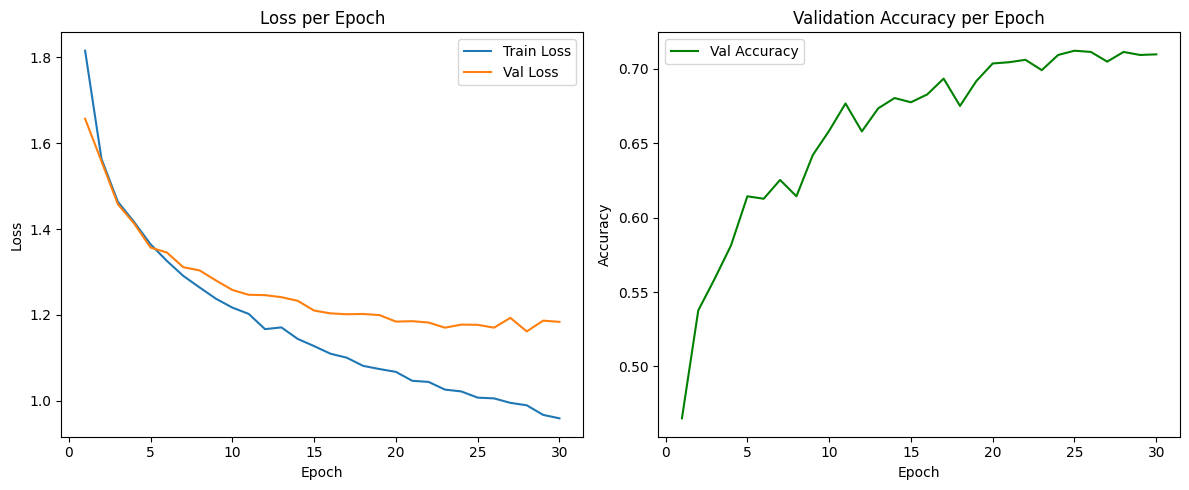

In [10]:
df = pd.read_csv("results\\training_log.csv")

plt.figure(figsize=(12, 5))
 
plt.subplot(1, 2, 1)
plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
plt.plot(df["epoch"], df["val_loss"],   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss per Epoch")
plt.legend()
 
plt.subplot(1, 2, 2)
plt.plot(df["epoch"], df["val_acc"], label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy per Epoch")
plt.legend()
 
plt.tight_layout()
plt.savefig("results\\training_plot.png", dpi=150)
plt.show()

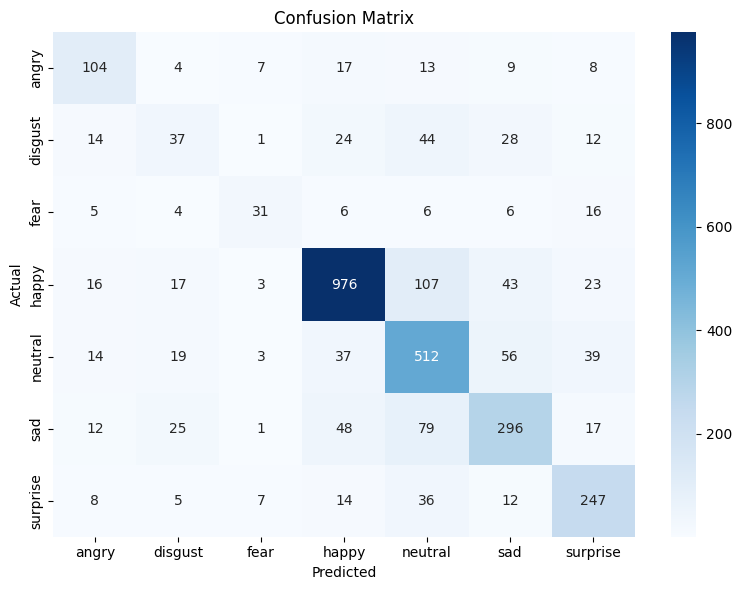


Classification Report:
              precision    recall  f1-score   support

       angry       0.60      0.64      0.62       162
     disgust       0.33      0.23      0.27       160
        fear       0.58      0.42      0.49        74
       happy       0.87      0.82      0.85      1185
     neutral       0.64      0.75      0.69       680
         sad       0.66      0.62      0.64       478
    surprise       0.68      0.75      0.71       329

    accuracy                           0.72      3068
   macro avg       0.62      0.61      0.61      3068
weighted avg       0.72      0.72      0.72      3068



In [11]:
model.load_state_dict(torch.load("results\\best_model.pth", map_location=device))
model.eval()
 
all_preds  = []
all_labels = []
 
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
 
        outputs = model(images)
        preds   = torch.argmax(outputs, dim=1)
 
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
 
# ===== CONFUSION MATRIX =====
cm = confusion_matrix(all_labels, all_preds)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("results\\confusion_matrix.png", dpi=150)
plt.show()
 
# ===== CLASSIFICATION REPORT =====
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))